### This notebook compute "VSS5. Index of women's participation in agricultural activity " indicator for the 27 basins of IKI Project

Spanish: Índice de la participación de las  en la actividad agropecuaria

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**  
**Status:** Complete and loaded in SQLite database.  
**QA Status:** reviewed by Scott Sheeder  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, reporte de INEI de Censos 2012

**Outputs:** 
 
**Assumptions:** Assigning index based on majority district. 
 
**Future work:** Look into using proportional method for these indices.
 
**Notes:** Seems like the metric is misleading. Percentages of >30 are assigned a value of one, then the legend in the chart indicates percentage. I would interprit 1 = 100 when in reality its 30. Should we somehow exclude COMIDs that do not have agricultural activity so that they are NaN and not 0?

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'nreynolds'
#user = 'sbakar'
#user = 'ssheeder'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 405 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

# productores = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/INEI_reporte_VSS5.xlsx'
productores = fr'C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/INEI_reporte_VSS5.xlsx'

In [6]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
productores = pd.read_excel(productores)

In [7]:
#FORMATTING THE DF
top_row_name= 'Unnamed: 0'

#remove empty rows 
productores = productores.dropna(axis=0, how='all')  # Drop rows that are completely NaN
#remove unnamed: 2 and and unnamed: 3 columns
productores = productores.drop(columns=[ 'Unnamed: 3'], errors='ignore')
#Keep only rows with 'Total' or 'AREA' in 'Temas de la capacitación' column
productores = productores[productores[top_row_name].str.contains('Total|AREA', case=False, na=False)]

#extract the district name from the dataframe and make a new column with just the district name
productores['District']= productores['Unnamed: 1'].str.split('Dist. ', expand=True)[1].str.strip()

indices_to_drop = []
# Iterate through the rows to check for AREA rows and their corresponding Total rows
for i in range(len(productores) - 1):  # Stop at the second-to-last row to avoid index errors
    if 'AREA' in str(productores.iloc[i][top_row_name]).upper():  # Check if the current row is an AREA row
        next_row = productores.iloc[i + 1]
        if 'TOTAL' in str(next_row[top_row_name]).upper():  # Check if the next row is a Total row
            # Assign the value from the next row to the "Total_Dist" column of the current row
            productores.at[productores.index[i], 'Total_Dist'] = next_row['Unnamed: 1']
            # Assign the value from the next row to the "Mujeres_Dist" column of the current row
            productores.at[productores.index[i], 'Mujeres_Dist'] = next_row['Unnamed: 2']
            # Mark the Total row for dropping
            indices_to_drop.append(productores.index[i + 1])


# Drop all marked indices at once
productores.drop(index=indices_to_drop, inplace=True)

# Reset the index after dropping rows
productores.reset_index(drop=True, inplace=True)

# Convert Total_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
productores['Total_Dist'] = pd.to_numeric(productores['Total_Dist'], errors='coerce').fillna(0)

# Convert Mujeres_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
productores['Mujeres_Dist'] = pd.to_numeric(productores['Mujeres_Dist'], errors='coerce').fillna(0)

#remove all rows from Temas that are NA
productores = productores.dropna(subset=[top_row_name])
#remove all rows from district that are NA
productores = productores.dropna(subset=['District'])

#Create column for District_ID by extracting the number after the # sign in the column Temas de la capacitación
productores['District_ID'] = productores[top_row_name].str.extract(r'(\d+)').astype(int) 

# Convert both columns to strings to be able to join them together
subbasins_gdf['IDDIST'] = subbasins_gdf['IDDIST'].astype(str)
productores['District_ID'] = productores['District_ID'].astype(str)

C:\Users\sbakar\AppData\Local\Temp\ipykernel_27200\3868406523.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  productores.at[productores.index[i], 'Mujeres_Dist'] = next_row['Unnamed: 2']


In [11]:
#CALCULATION AND SCORE

#divide Mujeres_Dist by Total_Dist to get percentage of women
productores['VSS5'] = productores['Mujeres_Dist'] / productores['Total_Dist'] * 100

#Score according to percentage: 
#less than or equal to 10% = 0
#between 10 and 20 inclusive= .25
#between 20 and 25  inclusive= .5
#between 25 and 29 inclusive= .75
#greater than or equal to 30% = 1
def score_percentage(percentage):
    if percentage <= 10:
        return 0
    elif 10 < percentage <= 20:
        return 0.25
    elif 20 < percentage <= 25:
        return 0.5
    elif 25 < percentage <= 29:
        return 0.75
    elif percentage >= 30:
        return 1
    else:
        return np.nan  # Handle unexpected cases
productores['VSS5_Score'] = productores['VSS5'].apply(score_percentage)

#merge VSS5 column back to subbasins_gdf based on IDDIST and District_ID
subbasins_gdf = subbasins_gdf.merge(productores[['District_ID', 'VSS5_Score']], left_on='IDDIST', right_on='District_ID', how='left')

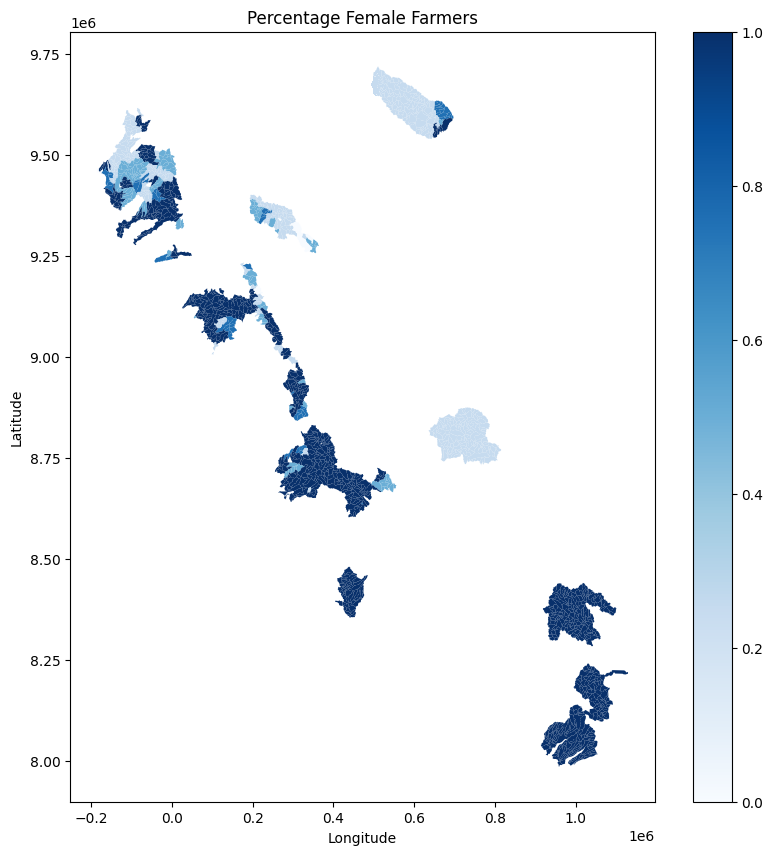

In [12]:
#PLOT THE RESULTS

subbasins_gdf.plot(column='VSS5_Score', cmap='Blues', legend=True, figsize=(10, 10))
plt.title('Percentage Female Farmers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [13]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'VSS5_Score' 

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

#use unique scenario IDs
scenario_ids_unique = sorted(set(scenario_ids))

for scn_id in scenario_ids_unique:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [14]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['VSS5_Score']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 405  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  VSS5_Score
0    min         0.0
1    max         1.0
2  count      1833.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [15]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()